# 06 — Link Prediction
Predizione di collaborazioni future tra attori usando metriche topologiche.

**Input:** `graph_data.pkl`  
**Output:** `link_predictions.csv`

**Approccio:**
1. Split train/test rimuovendo il 10% degli archi reali
2. Calcolo metriche su grafo di training
3. Valutazione con AUC su test set (archi reali vs non-archi)
4. Ranking finale delle collaborazioni più probabili


In [28]:
import pickle
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

random.seed(42)
np.random.seed(42)

PALETTE = ["#2D6A4F", "#40916C", "#52B788", "#74C69D", "#95D5B2",
           "#B7E4C7", "#D8F3DC", "#1B4332", "#081C15"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 100})

## 1. Caricamento

In [29]:
with open("risultati/graph_data.pkl", "rb") as f:
    data = pickle.load(f)

G = data["G_main"]
print(f"G_main: {G.number_of_nodes():,} nodi, {G.number_of_edges():,} archi")

G_main: 4,313 nodi, 29,944 archi


## 2. Sottografo top 500 attori

In [30]:
# Lavoriamo sui top 500 per degree per mantenere la rete densa
# e rendere il calcolo delle metriche fattibile su Colab
top_nodes = [n for n, _ in sorted(G.degree, key=lambda x: x[1], reverse=True)[:4000]]
subG = G.subgraph(top_nodes).copy()

print(f"SubG: {subG.number_of_nodes():,} nodi, {subG.number_of_edges():,} archi")
print(f"Densità: {nx.density(subG):.4f}")

SubG: 4,000 nodi, 29,315 archi
Densità: 0.0037


## 3. Train/Test split
Rimuoviamo il 10% degli archi reali come test set.
Il modello viene addestrato su `G_train` e valutato su questi archi rimossi.

In [31]:
edges_all = list(subG.edges())
n_test    = int(0.1 * len(edges_all))

# Campionamento riproducibile
test_edges  = random.sample(edges_all, n_test)
train_edges = [e for e in edges_all if e not in set(map(tuple, test_edges))]

# Grafo di training senza gli archi di test
G_train = nx.Graph()
G_train.add_nodes_from(subG.nodes(data=True))
G_train.add_edges_from(
    [(u, v, subG[u][v]) for u, v in train_edges]
)

print(f"Archi training: {G_train.number_of_edges():,}")
print(f"Archi test:     {len(test_edges):,}")

Archi training: 26,384
Archi test:     2,931


## 4. Campionamento non-archi
Per la valutazione servono esempi negativi (coppie che non collaborano).
Campionamento bilanciato: stesso numero di archi reali rimossi.

In [32]:
# Campiona non-archi in numero uguale agli archi di test (bilanciato)
non_edges_all = list(nx.non_edges(G_train))
non_edges     = random.sample(non_edges_all, min(len(test_edges) * 10, len(non_edges_all)))

print(f"Non-archi campionati: {len(non_edges):,}")
print(f"Ratio neg/pos nel test: {len(non_edges)/len(test_edges):.1f}x")

Non-archi campionati: 29,310
Ratio neg/pos nel test: 10.0x


## 5. Calcolo metriche di link prediction

| Metrica | Cosa misura |
|---|---|
| Common Neighbors | Vicini in comune assoluti |
| Jaccard | Vicini in comune normalizzati sulla union |
| Adamic-Adar | Vicini comuni pesati per rarità del vicino |
| Resource Allocation | Simile ad AA ma più penalizzante per hub |

In [33]:
def compute_metrics(G, pairs):
    """Calcola le 4 metriche per una lista di coppie (u, v)."""
    cn = {(u, v): len(list(nx.common_neighbors(G, u, v))) for u, v in pairs}
    jc = {(u, v): s for u, v, s in nx.jaccard_coefficient(G, pairs)}
    aa = {(u, v): s for u, v, s in nx.adamic_adar_index(G, pairs)}
    ra = {(u, v): s for u, v, s in nx.resource_allocation_index(G, pairs)}

    df = pd.DataFrame(pairs, columns=["actor_a", "actor_b"])
    df["common_neighbors"] = df.apply(lambda r: cn[(r.actor_a, r.actor_b)], axis=1)
    df["jaccard"]          = df.apply(lambda r: jc[(r.actor_a, r.actor_b)], axis=1)
    df["adamic_adar"]      = df.apply(lambda r: aa[(r.actor_a, r.actor_b)], axis=1)
    df["resource_alloc"]   = df.apply(lambda r: ra[(r.actor_a, r.actor_b)], axis=1)
    return df

print("Calcolo metriche su test edges (positivi)...")
df_pos = compute_metrics(G_train, test_edges)
df_pos["label"] = 1

print("Calcolo metriche su non-edges (negativi)...")
df_neg = compute_metrics(G_train, non_edges)
df_neg["label"] = 0

df_eval = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"Dataset valutazione: {len(df_eval):,} coppie ({df_pos['label'].sum():,} pos, {df_neg['label'].sum():,} neg)")

Calcolo metriche su test edges (positivi)...
Calcolo metriche su non-edges (negativi)...
Dataset valutazione: 32,241 coppie (2,931 pos, 0 neg)


## 6. Normalizzazione e score composito

In [34]:
metrics = ["common_neighbors", "jaccard", "adamic_adar", "resource_alloc"]

scaler = MinMaxScaler()
df_eval[metrics] = scaler.fit_transform(df_eval[metrics])

# Score composito con pesi uguali
# Nota: i pesi sono arbitrari — una versione più rigorosa
# userebbe un modello supervisionato (es. LogisticRegression su queste 4 feature)
df_eval["score"] = df_eval[metrics].mean(axis=1)

## 7. Valutazione — AUC e Precision-Recall

In [35]:
y_true = df_eval["label"].values
y_score = df_eval["score"].values

auc_roc = roc_auc_score(y_true, y_score)
auc_pr  = average_precision_score(y_true, y_score)

print(f"AUC-ROC:             {auc_roc:.4f}  (0.5 = random, 1.0 = perfetto)")
print(f"Average Precision:   {auc_pr:.4f}")

# AUC per singola metrica
print("\nAUC-ROC per singola metrica:")
for m in metrics:
    auc_m = roc_auc_score(y_true, df_eval[m].values)
    print(f"  {m:<22} {auc_m:.4f}")

AUC-ROC:             0.9607  (0.5 = random, 1.0 = perfetto)
Average Precision:   0.8369

AUC-ROC per singola metrica:
  common_neighbors       0.9550
  jaccard                0.9523
  adamic_adar            0.9604
  resource_alloc         0.9602


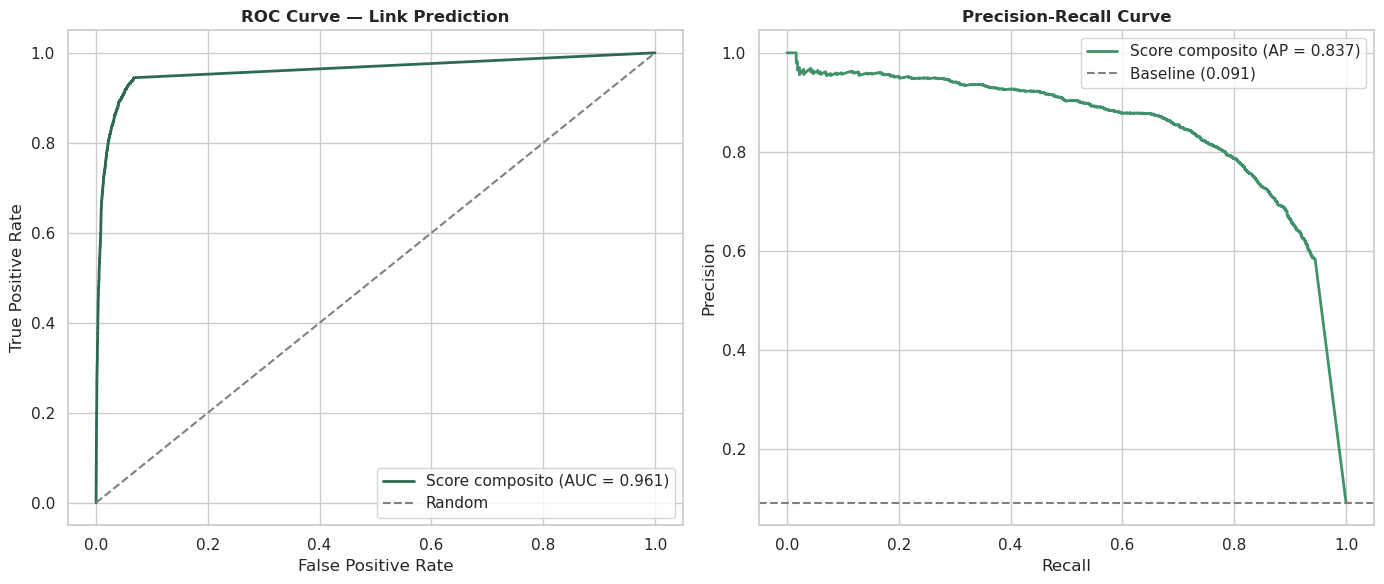

In [36]:
# Plot ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_score)
axes[0].plot(fpr, tpr, color=PALETTE[0], lw=2,
             label=f"Score composito (AUC = {auc_roc:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[0].set_title("ROC Curve — Link Prediction", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_true, y_score)
axes[1].plot(rec, prec, color=PALETTE[1], lw=2,
             label=f"Score composito (AP = {auc_pr:.3f})")
baseline = y_true.mean()
axes[1].axhline(baseline, color="gray", linestyle="--",
                label=f"Baseline ({baseline:.3f})")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

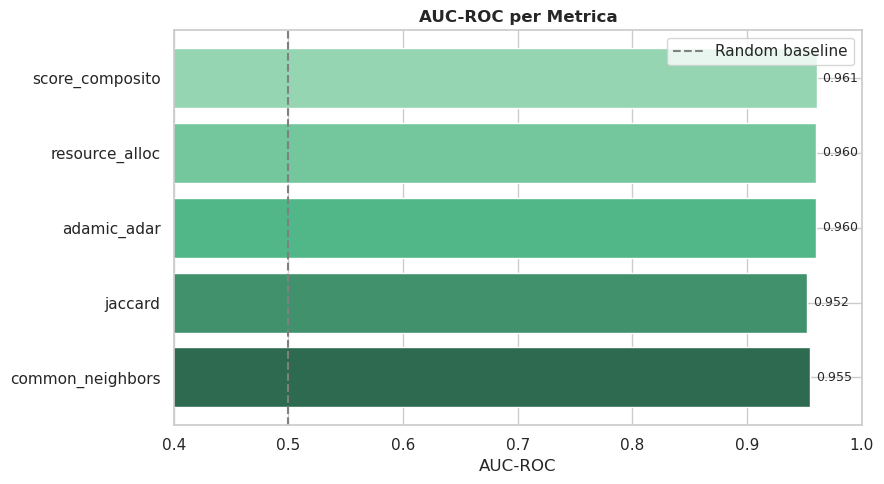

In [37]:
# Confronto AUC singole metriche — barplot
auc_scores = {m: roc_auc_score(y_true, df_eval[m].values) for m in metrics}
auc_scores["score_composito"] = auc_roc

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(list(auc_scores.keys()), list(auc_scores.values()),
               color=[PALETTE[i % len(PALETTE)] for i in range(len(auc_scores))])
ax.axvline(0.5, color="gray", linestyle="--", label="Random baseline")
ax.set_title("AUC-ROC per Metrica", fontweight="bold")
ax.set_xlabel("AUC-ROC")
ax.set_xlim(0.4, 1.0)
for bar, val in zip(bars, auc_scores.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Predizioni finali su tutti i non-archi
Ora che abbiamo validato il modello, lo applichiamo su un campione ampio di non-archi
per trovare le collaborazioni future più probabili.

In [38]:
print("Calcolo metriche su campione ampio di non-archi...")
non_edges_full = random.sample(
    list(nx.non_edges(subG)),
    min(50000, len(list(nx.non_edges(subG))))
)

df_full = compute_metrics(subG, non_edges_full)

# Normalizza con lo stesso scaler fittato sul training
df_full[metrics] = scaler.transform(df_full[metrics])
df_full["score"] = df_full[metrics].mean(axis=1)

df_pred = df_full.sort_values("score", ascending=False).reset_index(drop=True)
print(f"Coppie analizzate: {len(df_pred):,}")
print(f"\nTop 20 collaborazioni predette:")
for _, row in df_pred.head(20).iterrows():
    print(f"  {row['actor_a']:<25} ↔ {row['actor_b']:<25} | score: {row['score']:.4f}")

Calcolo metriche su campione ampio di non-archi...
Coppie analizzate: 50,000

Top 20 collaborazioni predette:
  Woody Harrelson           ↔ Matt Damon                | score: 0.4433
  Aamir Khan                ↔ Akshay Kumar              | score: 0.4197
  Susan Sarandon            ↔ Owen Wilson               | score: 0.3525
  Johnny Depp               ↔ Matthew Mcconaughey       | score: 0.3507
  Matt Damon                ↔ Cameron Diaz              | score: 0.3098
  Jamie Foxx                ↔ Nicole Kidman             | score: 0.2841
  Tom Hanks                 ↔ Matthew Broderick         | score: 0.2840
  Julianne Moore            ↔ Chris Cooper              | score: 0.2791
  Alec Baldwin              ↔ Toni Collette             | score: 0.2667
  Alan Arkin                ↔ Sandra Bullock            | score: 0.2621
  Don Cheadle               ↔ Russell Crowe             | score: 0.2569
  Denzel Washington         ↔ Greg Kinnear              | score: 0.2529
  Susan Sarandon          

## 9. Distribuzione degli score

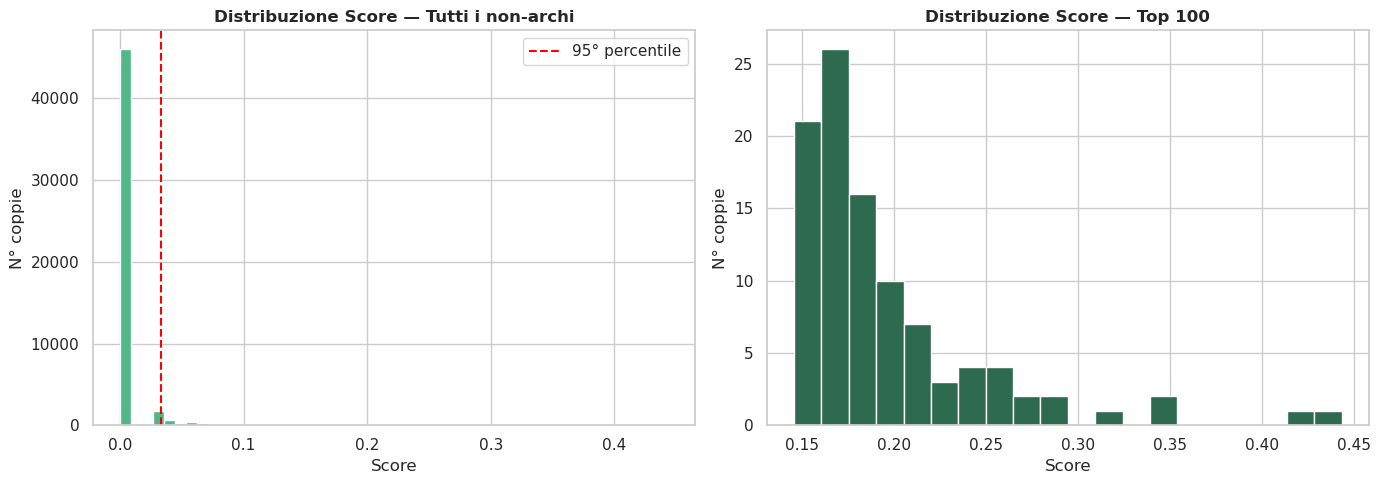

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione score
axes[0].hist(df_pred["score"], bins=50, color=PALETTE[2], edgecolor="white")
axes[0].axvline(df_pred["score"].quantile(0.95), color="red", linestyle="--",
                label="95° percentile")
axes[0].set_title("Distribuzione Score — Tutti i non-archi", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("N° coppie")
axes[0].legend()

# Top 100 score
top100 = df_pred.head(100)
axes[1].hist(top100["score"], bins=20, color=PALETTE[0], edgecolor="white")
axes[1].set_title("Distribuzione Score — Top 100", fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("N° coppie")

plt.tight_layout()
plt.show()

## 10. Salvataggio

In [40]:
top_100 = df_pred.head(100)
top_100.to_csv("risultati/link_predictions.csv", index=False)

print("✓ link_predictions.csv salvato")
print(f"  {len(top_100)} predizioni con score > {top_100['score'].min():.4f}")
print(f"\nAUC-ROC finale: {auc_roc:.4f}")
print(f"Average Precision: {auc_pr:.4f}")

✓ link_predictions.csv salvato
  100 predizioni con score > 0.1453

AUC-ROC finale: 0.9607
Average Precision: 0.8369


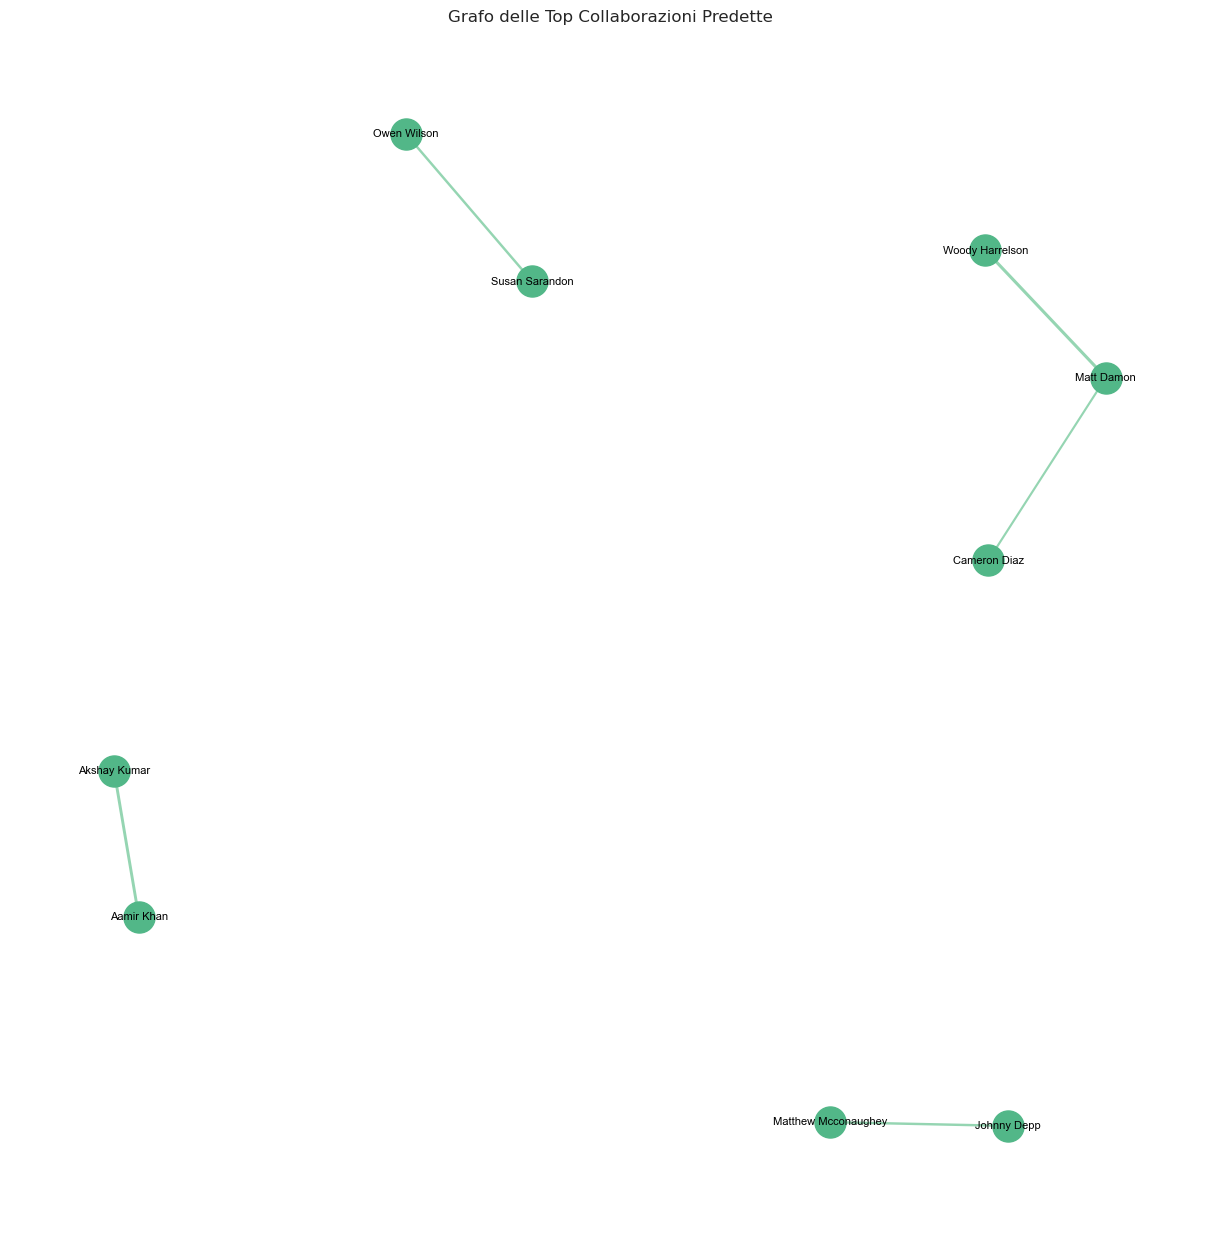

In [41]:
def plot_prediction_graph(df_top, min_score=0.3):
    G_pred = nx.Graph()
    for _, row in df_top.iterrows():
        if row['score'] > min_score:
            G_pred.add_edge(row['actor_a'], row['actor_b'], weight=row['score'])
    
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G_pred, k=0.5)
    weights = [G_pred[u][v]['weight'] * 5 for u, v in G_pred.edges()]
    
    nx.draw(G_pred, pos, with_labels=True, width=weights, 
            node_color=PALETTE[2], edge_color=PALETTE[4], 
            node_size=500, font_size=8)
    plt.title("Grafo delle Top Collaborazioni Predette")
    plt.show()

plot_prediction_graph(top_100.head(50))